# Integrantes

Raul Adolfo Morales Galindo

Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import kagglehub
import seaborn as sns

# Descripción del Dataset


Nombre del dataset: Medical Cost Personal Dataset

Fuente: https://www.kaggle.com/datasets/mirichoi0218/insurance

variables independientes:

*   age: edad del paciente.
*   sex: sexo.
*   bmi: índice de masa corporal.
*   children: número de hijos a cargo.
*   smoker: si el paciente fuma o no.
*   region: región geográfica.

Variable dependiente:
*   charges: costos del seguro médico.

Tamaño del dataset: 1338 registros



In [2]:
# Download dataset
path = kagglehub.dataset_download("mirichoi0218/insurance")

# Read dataset
df = pd.read_csv(path + "/insurance.csv")

# Visualización de relaciones entre variables

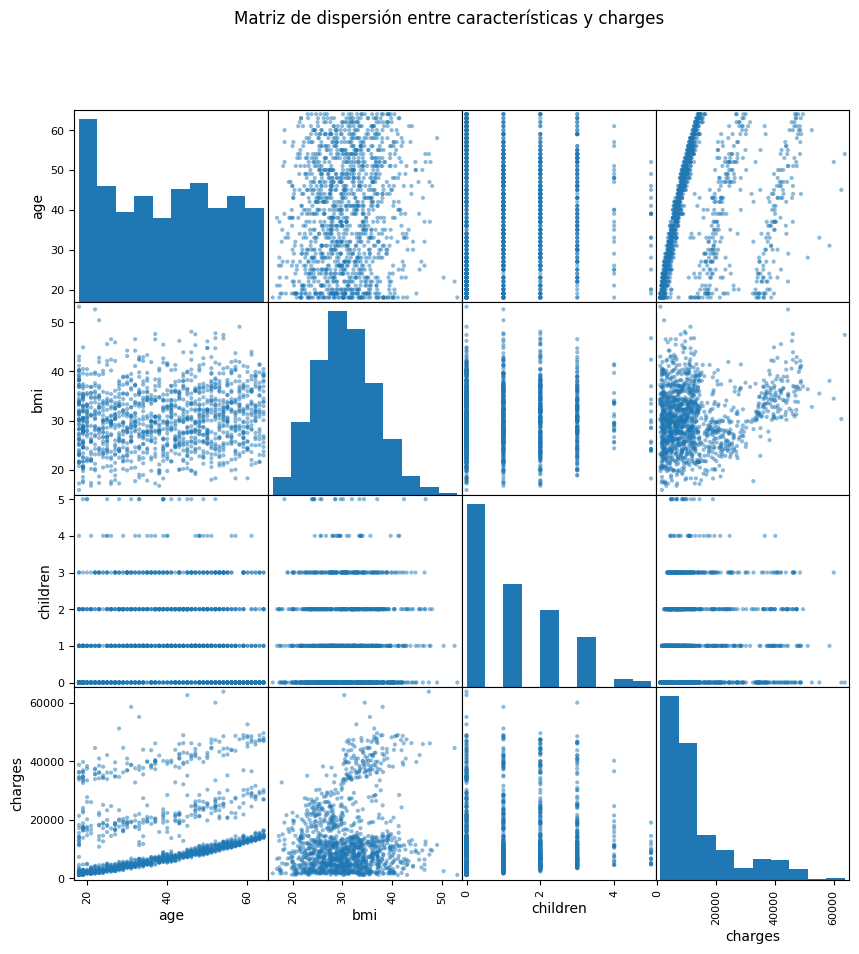

In [3]:
df = pd.get_dummies(df, drop_first=True)
scatter_matrix(df[['age', 'bmi', 'children', 'charges']], figsize=(10, 10))
plt.suptitle("Matriz de dispersión entre características y charges")
plt.show()

relaciones:


*   age-charges: relación creciente.
*   bmi-charges: ligera tendencia ascendente, pero no fuerte.
*   children-charges: sin una relación clara lineal.



#  Entrenamiento del modelo

In [4]:
def train_and_evaluate(split_ratio):
    test_size = 1 - split_ratio
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Train/Test = {int(split_ratio*100)}/{int(test_size*100)} --> MSE: {mse:.2f}, R²: {r2:.4f}")

In [5]:
X = df.drop("charges", axis=1)
y = df["charges"]

for ratio in [0.7, 0.5, 0.4]:
    train_and_evaluate(ratio)

Train/Test = 70/30 --> MSE: 33780509.57, R²: 0.7696
Train/Test = 50/50 --> MSE: 35276395.61, R²: 0.7742
Train/Test = 40/60 --> MSE: 34956620.53, R²: 0.7734


El desempeño del modelo se ve afectado por la proporción del conjunto de datos utilizada para el entrenamiento y la prueba, ya que esta distribución influye directamente en la capacidad del modelo para aprender patrones representativos y en su generalización a datos no vistos.


En este caso, aunque la proporción 50/50 presenta un R² ligeramente mayor (0.7742), el valor de MSE también es más alto, cosa que indica que las predicciones están en promedio más alejadas de los valores reales. por otro lado, la proporción 70/30 obtiene el MSE mas bajo, lo que indica mayor precisión en términos absolutos a pesar de tener un R² ligeramente menor.

Debido a que el objetivo del modelo es estimar costos de seguros con la mayor precisión posible, se toma a la configuracion de 70% entrenamiento / 30% prueba como la mejor opción. Esta configuración permite un entrenamiento más robusto con más datos y produce un error medio más bajo, lo que resulta favorable en aplicaciones prácticas.

# 4. Cambio del optimizador

In [6]:
from sklearn.linear_model import SGDRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

sgd = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)
sgd.fit(X_train, y_train)
y_pred_sgd = sgd.predict(X_test)

print("SGD --> MSE:", mean_squared_error(y_test, y_pred_sgd), "R2:", r2_score(y_test, y_pred_sgd))

SGD --> MSE: 6.298844726850845e+18 R2: -42959075593.74443


El modelo entrenado con SGD presentó un desempeño considerablemente peor que el modelo de regresión lineal clásico, El error cuadrático medio se incrementó de forma drástica y el coeficiente de determinación R² fue negativo, lo cual indica que el modelo no solo no generaliza bien, sino que realiza predicciones peores que simplemente usar la media de los valores observados.

En este caso, dado que el dataset es pequeño y manejable, la regresión lineal tradicional sigue siendo una mejor opción por su estabilidad y precisión.

# 5. Regularización L2 (Ridge)

In [7]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print("Ridge --> MSE:", mean_squared_error(y_test, y_pred_ridge), "R2:", r2_score(y_test, y_pred_ridge))


Ridge --> MSE: 33818241.88764884 R2: 0.7693544653450765


Primero,se obtuvieron las métricas de evaluación del modelo final usando una partición 70% entrenamiento y 30% prueba. El MSE fue de 33,818,241.89, lo que indica un error cuadrático medio aceptable en unidades monetarias, mientras que el R² fue de 0.7694, lo que significa que el modelo explica aproximadamente el 77% de la variabilidad en los costos del seguro médico.

La regularización mediante Ridge produjo resultados muy similares a los de la regresión lineal sin regularización. El MSE aumentó ligeramente y el R² disminuyó mínimamente, lo cual indica que el modelo regularizado no sufrió pérdida significativa de rendimiento, pero puede haber ganado en estabilidad de los coeficientes.

Esto es coherente con la naturaleza del dataset, que no presenta muchas características altamente correlacionadas ni ruido extremo

# 6. Modelo final

In [8]:
print("Pesos del modelo Ridge:")
coef_df = pd.DataFrame({'Feature': X.columns,'Weight': ridge.coef_})
print(coef_df)
print("Intercepto:", ridge.intercept_)


Pesos del modelo Ridge:
            Feature        Weight
0               age    261.102955
1               bmi    348.612333
2          children    425.247412
3          sex_male    110.684662
4        smoker_yes  23475.265709
5  region_northwest   -480.029237
6  region_southeast   -953.061595
7  region_southwest   -914.211640
Intercepto: -12338.960683130652


Dado que Ridge no deterioró el rendimiento y puede aportar mayor estabilidad, se seleccionó como parte del modelo final, junto con:

Proporción de datos: 70% entrenamiento / 30% prueba

Optimizador: Algoritmo cerrado (no SGD)

Regularización: Ridge con α = 1.0

Los parámetros obtenidos indican el peso de cada característica en la predicción del costo del seguro. Un coeficiente positivo implica que al aumentar esa variable, se incrementa el costo, uno negativo, lo contrario. La magnitud indica la fuerza del efecto.



In [9]:
mse = mean_squared_error(y_test, y_pred_ridge)
r2 = r2_score(y_test, y_pred_ridge)

print("MSE final:", mse)
print("R² final:", r2)


MSE final: 33818241.88764884
R² final: 0.7693544653450765


Las metricas finales son muy parecidas al modelo de regresion lineal sin regularizacion lo que indica, como se comento anteriormente, que el modelo no presento perdidas en desempeño o rendimiento.



# Graficas adicionales

<ipython-input-10-c28869c4589f>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=split_labels, y=mse_values, palette="Blues")


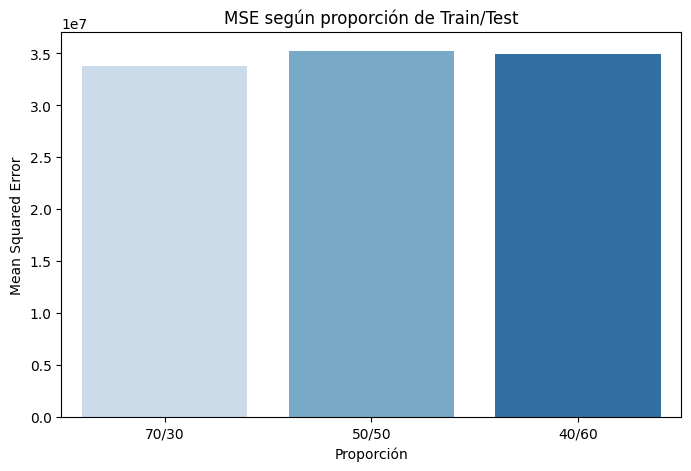

In [10]:
split_labels = ["70/30", "50/50", "40/60"]
mse_values = [33780509.57, 35276395.61, 34956620.53]

plt.figure(figsize=(8, 5))
sns.barplot(x=split_labels, y=mse_values, palette="Blues")
plt.title("MSE según proporción de Train/Test")
plt.ylabel("Mean Squared Error")
plt.xlabel("Proporción")
plt.show()

Al comparar las diferentes proporciones de entrenamiento/prueba, se logra observar que la partición 70/30 ofreció el menor error cuadrático medio (MSE), lo que sugiere que tener un mayor conjunto de datos para entrenar el modelo mejora su capacidad de aprendizaje y precisión en las predicciones. Proporciones con menos datos de entrenamiento (como 50/50 o 40/60) resultaron en errores más altos.

<ipython-input-11-1c8e199fdd80>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=mse_vals, ax=ax[0], palette="Oranges_r")
<ipython-input-11-1c8e199fdd80>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=r2_vals, ax=ax[1], palette="Greens_r")


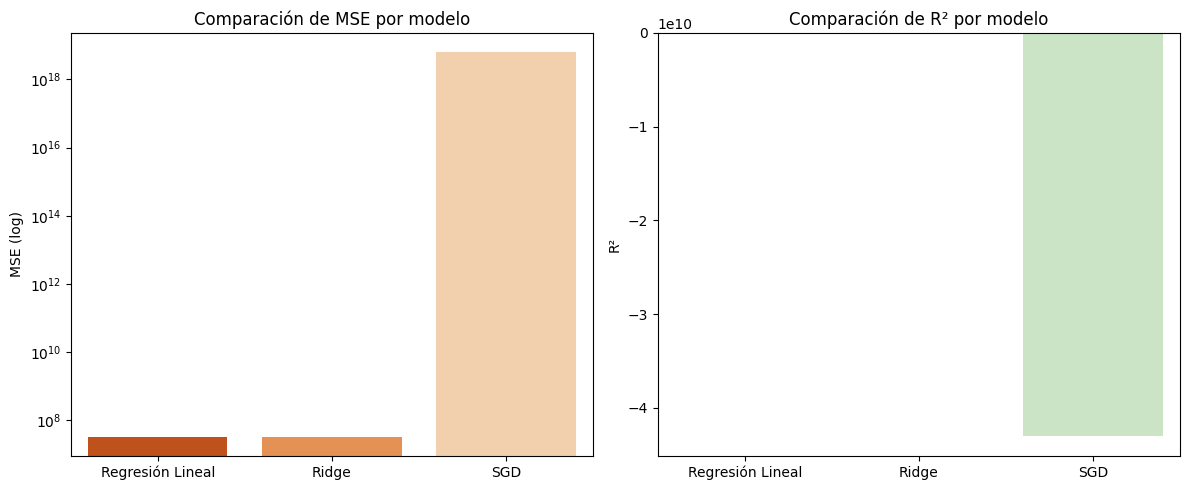

In [11]:
model_names = ["Regresión Lineal", "Ridge", "SGD"]
mse_vals = [33780509.57, 33818241.89, 6.298e+18]
r2_vals = [0.7696, 0.7694, -42959075593.74]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# MSE
sns.barplot(x=model_names, y=mse_vals, ax=ax[0], palette="Oranges_r")
ax[0].set_title("Comparación de MSE por modelo")
ax[0].set_ylabel("MSE (log)")
ax[0].set_yscale('log')  # para manejar el valor de SGD

# R²
sns.barplot(x=model_names, y=r2_vals, ax=ax[1], palette="Greens_r")
ax[1].set_title("Comparación de R² por modelo")
ax[1].set_ylabel("R²")

plt.tight_layout()
plt.show()


La comparación entre los tres modelos mostró que tanto la regresión lineal estándar como el modelo con regularización Ridge obtuvieron resultados similares y estables. por otra parte, el modelo con SDG tuvo un desempeño bastante malo, con un error extremadamente alto y un R² negativo. Esto confirma que SGD no es adecuado con los parámetros por defecto para este conjunto de datos, y destaca la robustez de los métodos deterministas en problemas pequeños o medianos.

<ipython-input-12-4bac8449e83e>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Feature', data=coef_df, palette="coolwarm")


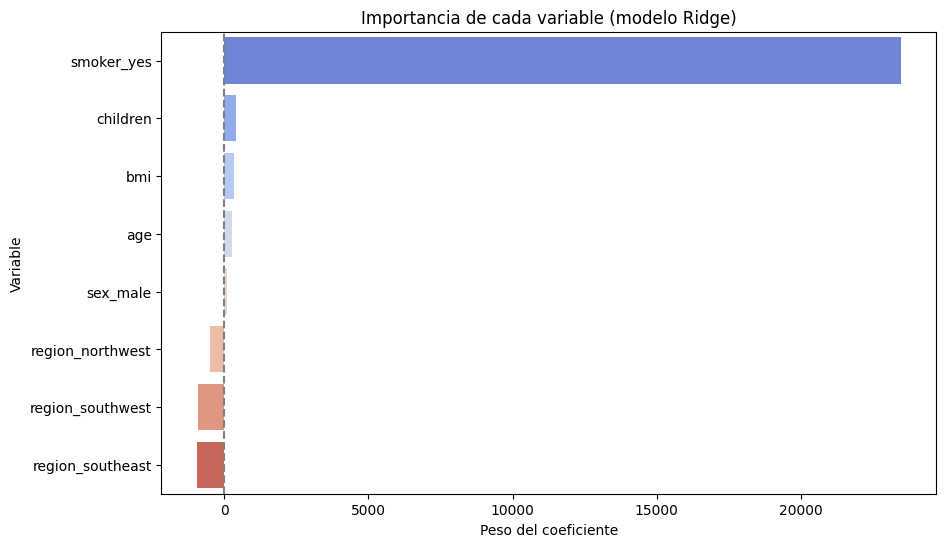

In [12]:
X = df.drop('charges', axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

coef_df = pd.DataFrame({'Feature': X.columns, 'Coeficiente': ridge.coef_}).sort_values(by='Coeficiente', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficiente', y='Feature', data=coef_df, palette="coolwarm")
plt.title("Importancia de cada variable (modelo Ridge)")
plt.xlabel("Peso del coeficiente")
plt.ylabel("Variable")
plt.axvline(0, color='gray', linestyle='--')
plt.show()


El gráfico de coeficientes del modelo Ridge reveló que la variable más influyente en el costo del seguro es smoker_yes, con un coeficiente altamente positivo. Esto indica que ser fumador aumenta considerablemente el costo esperado del seguro médico. Otras variables con peso significativo fueron age, bmi, y children. Las variables categóricas como sex_male o region tuvieron efectos menores.

# Conclusiones


se aplicaron técnicas de regresión lineal para predecir el costo de un seguro médico utilizando variables como edad, IMC, hábito de fumar, entre otras. Se probaron distintas proporciones de entrenamiento y prueba, observando que la división 70/30 ofreció el mejor desempeño en términos de precisión (es decir MSE más bajo). Al evaluar diferentes métodos de optimización, se concluyó que SGD requiere una cuidadosa configuración para funcionar correctamente, ya que generó resultados erráticos con los parámetros por defecto. La aplicación de regularización L2 (Ridge) no mejoró significativamente el rendimiento, pero ofreció mayor estabilidad en los coeficientes del modelo. Las métricas finales (MSE de 33.8 millones y R² de 0.7694) indican que el modelo tiene un buen poder predictivo. En resumen, se comprobó la importancia de seleccionar adecuadamente tanto la proporción de datos de entrenamiento como las técnicas de optimización y regularización para lograr un modelo robusto y generalizable. Estas prácticas son fundamentales en proyectos de machine learning aplicables al mundo real.